In [1]:
!pip install pennylane pennylane-lightning scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 14.0 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1


In [4]:
import pennylane as qml

# Query the database index for all available qspin datasets
available_qspin = qml.data.list_datasets()["qspin"]
print("Available systems in qspin:", list(available_qspin.keys()))

# Inspect details for each available system
for sysname in available_qspin.keys():
    print(f"\nSystem: {sysname}")
    print(available_qspin[sysname])

Available systems in qspin: ['FermiHubbard', 'Heisenberg', 'Ising', 'BoseHubbard']

System: FermiHubbard
{'closed': {'chain': ['1x4', '1x8'], 'rectangular': ['2x2', '2x4']}, 'open': {'chain': ['1x4', '1x8'], 'rectangular': ['2x2', '2x4']}}

System: Heisenberg
{'closed': {'chain': ['1x16', '1x4', '1x8'], 'rectangular': ['2x2', '2x4', '2x8', '4x4']}, 'open': {'chain': ['1x16', '1x4', '1x8'], 'rectangular': ['2x2', '2x4', '2x8', '4x4']}}

System: Ising
{'closed': {'chain': ['1x16', '1x4', '1x8'], 'rectangular': ['2x2', '2x4', '2x8', '4x4']}, 'open': {'chain': ['1x16', '1x4', '1x8'], 'rectangular': ['2x2', '2x4', '2x8', '4x4']}}

System: BoseHubbard
{'closed': {'chain': ['1x4', '1x8'], 'rectangular': ['2x2', '2x4']}, 'open': {'chain': ['1x4', '1x8'], 'rectangular': ['2x2', '2x4']}}


---
---
---

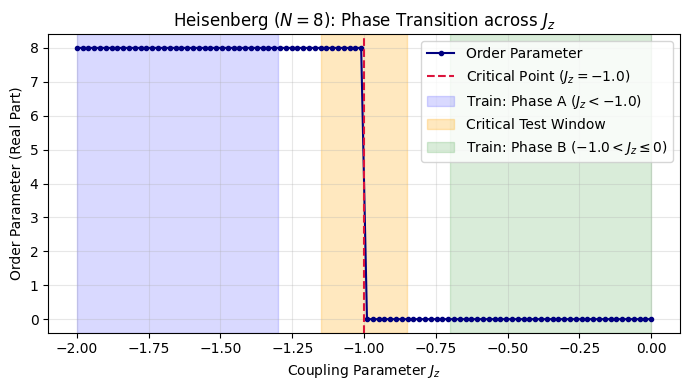

In [13]:
# import matplotlib.pyplot as plt
# import numpy as np

# jz_vals = np.array(heis_ds.parameters['Jz'])
# # Extract the real component to avoid complex casting warnings
# order_vals = np.array(heis_ds.order_params).real

# plt.figure(figsize=(7, 4))
# plt.plot(jz_vals, order_vals, 'o-', color='navy', markersize=3, label='Order Parameter')
# plt.axvline(x=-1.0, color='crimson', linestyle='--', label=r'Critical Point ($J_z = -1.0$)')

# # Visual zones using raw strings and standard LaTeX
# plt.axvspan(-2.0, -1.3, color='blue', alpha=0.15, label=r'Train: Phase A ($J_z < -1.0$)')
# plt.axvspan(-1.15, -0.85, color='orange', alpha=0.25, label='Critical Test Window')
# plt.axvspan(-0.7, 0.0, color='green', alpha=0.15, label=r'Train: Phase B ($-1.0 < J_z \leq 0$)')

# plt.title(r"Heisenberg ($N=8$): Phase Transition across $J_z$")
# plt.xlabel(r"Coupling Parameter $J_z$")
# plt.ylabel("Order Parameter (Real Part)")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [22]:
# import pennylane as qml
# import numpy as np

# # 1. Load N=16 Heisenberg dataset
# print("Loading Heisenberg (N=16) dataset...")
# heis_16_ds = qml.data.load("qspin", sysname="Heisenberg", periodicity="open", lattice="chain", layout="1x16")[0]

# jz_16 = np.array(heis_16_ds.parameters['Jz'])
# states_16 = heis_16_ds.ground_states

# # 2. Build the N=16 circuit instance using the recursive model
# qcnn_16 = build_qcnn_model(16)

# # 3. Select clean evaluation states across both phases
# eval_indices_16 = []
# true_labels_16 = []

# for idx, jz in enumerate(jz_16):
#     if jz <= -1.4:
#         eval_indices_16.append(idx)
#         true_labels_16.append(0)  # Phase A
#     elif jz >= -0.6:
#         eval_indices_16.append(idx)
#         true_labels_16.append(1)  # Phase B

# # Sample 10 representative states (balanced across phases)
# np.random.seed(42)
# sampled_idx = np.random.choice(len(eval_indices_16), size=10, replace=False)

# # 4. Run zero-shot evaluation with budget accounting
# meter_16 = CopyMeter(max_budget=64)
# k_budget = 32
# correct_count = 0

# print(f"\nEvaluating zero-shot transfer on {len(sampled_idx)} states (N=16, k={k_budget} copies)...")
# print("------------------------------------------------------------------")

# for i in sampled_idx:
#     st_idx = eval_indices_16[i]
#     y_true = true_labels_16[i]
#     psi = np.array(states_16[st_idx], dtype=np.complex128)

#     # Audit physical copies
#     meter_16.reset_for_new_state()
#     meter_16.consume(k_budget)

#     # Run the 16-qubit circuit with identical 5 params
#     samples = qml.set_shots(qcnn_16, shots=k_budget)(params, psi)
#     emp_expval = np.mean(samples)
#     y_pred = 0 if emp_expval >= 0.0 else 1

#     match_status = "✓" if y_pred == y_true else "✗"
#     phase_str = "Phase A" if y_true == 0 else "Phase B"
#     print(f"Jz: {jz_16[st_idx]:.2f} | True: {phase_str} | <Z>: {emp_expval:+0.3f} | Pred: {y_pred} [{match_status}]")

#     if y_pred == y_true:
#         correct_count += 1

# print("------------------------------------------------------------------")
# print(f"Zero-Shot N=16 Accuracy: {(correct_count / len(sampled_idx)) * 100:.1f}%")
# print(f"Total Physical Copies Audited: {sum(meter_16.history)}")

Loading Heisenberg (N=16) dataset...

Evaluating zero-shot transfer on 10 states (N=16, k=32 copies)...
------------------------------------------------------------------
Jz: 0.00 | True: Phase B | <Z>: -0.188 | Pred: 1 [✓]
Jz: -0.10 | True: Phase B | <Z>: +0.188 | Pred: 0 [✗]
Jz: -1.54 | True: Phase A | <Z>: +0.500 | Pred: 0 [✓]
Jz: -1.72 | True: Phase A | <Z>: +0.312 | Pred: 0 [✓]
Jz: -0.26 | True: Phase B | <Z>: +0.312 | Pred: 0 [✗]
Jz: -1.90 | True: Phase A | <Z>: +0.188 | Pred: 0 [✓]
Jz: -1.47 | True: Phase A | <Z>: +0.188 | Pred: 0 [✓]
Jz: -1.78 | True: Phase A | <Z>: +0.375 | Pred: 0 [✓]
Jz: -0.24 | True: Phase B | <Z>: +0.062 | Pred: 0 [✗]
Jz: -1.96 | True: Phase A | <Z>: -0.062 | Pred: 1 [✗]
------------------------------------------------------------------
Zero-Shot N=16 Accuracy: 60.0%
Total Physical Copies Audited: 288


In [27]:
# from sklearn.metrics import classification_report

# # 1. Sample 10 FermiHubbard states (dim=65536, N=16)
# np.random.seed(99)
# fermi_idx = np.random.choice(len(fermi_ds.ground_states), size=10, replace=False)
# fermi_test_states = [np.array(fermi_ds.ground_states[i], dtype=np.complex128) for i in fermi_idx]

# # 2. Build test batch
# test_records = []

# # Add Heisenberg N=8 critical & off-critical states
# for s, l in zip(crit_test_states[:6], crit_test_labels[:6]):
#     test_records.append((s, l, 8, "Heis-Crit"))

# # Add Heisenberg N=16 states
# for i in sampled_idx[:6]:
#     st_idx = eval_indices_16[i]
#     test_records.append((np.array(states_16[st_idx], dtype=np.complex128), true_labels_16[i], 16, "Heis-16"))

# # Add FermiHubbard N=16 impostor states (True class = 2)
# for s in fermi_test_states:
#     test_records.append((s, 2, 16, "FermiHubbard-OOD"))

# # 3. Run Benchmark under budget k=32
# meter_3class = CopyMeter(max_budget=64)
# k_budget = 32

# y_true_all = []
# y_pred_all = []

# print(f"Running 3-Class Benchmark (k = {k_budget} copies per state)...")
# print("-------------------------------------------------------------------------")
# print(f"{'Source':<18} | {'True':<6} | {'<Z>':<7} | {'Pred':<6} | {'Status'}")
# print("-------------------------------------------------------------------------")

# for state, true_lbl, n_q, tag in test_records:
#     pred_lbl, emp_z = predict_3class(params, state, k=k_budget, meter=meter_3class, num_qubits=n_q, tau=tau)
#     y_true_all.append(true_lbl)
#     y_pred_all.append(pred_lbl)

#     status = "✓" if pred_lbl == true_lbl else "✗"
#     print(f"{tag:<18} | {true_lbl:<6} | {emp_z:+0.3f}  | {pred_lbl:<6} | [{status}]")

# print("-------------------------------------------------------------------------")
# print(f"Total Physical Copies Audited: {sum(meter_3class.history)}")
# print("\nClassification Report (Macro-F1 across all 3 classes):")
# print(classification_report(y_true_all, y_pred_all, target_names=["Phase A", "Phase B", "Unknown/OOD"], zero_division=0))

Running 3-Class Benchmark (k = 32 copies per state)...
-------------------------------------------------------------------------
Source             | True   | <Z>     | Pred   | Status
-------------------------------------------------------------------------
Heis-Crit          | 1      | +0.000  | 2      | [✗]
Heis-Crit          | 1      | -0.562  | 1      | [✓]
Heis-Crit          | 1      | -0.625  | 1      | [✓]
Heis-Crit          | 1      | -0.312  | 1      | [✓]
Heis-Crit          | 1      | -0.375  | 1      | [✓]
Heis-Crit          | 1      | -0.062  | 2      | [✗]
Heis-16            | 1      | +0.250  | 0      | [✗]
Heis-16            | 1      | -0.188  | 2      | [✗]
Heis-16            | 0      | +0.188  | 2      | [✗]
Heis-16            | 0      | +0.125  | 2      | [✗]
Heis-16            | 1      | -0.250  | 1      | [✓]
Heis-16            | 0      | +0.250  | 0      | [✓]
FermiHubbard-OOD   | 2      | -0.125  | 2      | [✓]
FermiHubbard-OOD   | 2      | +0.312  | 0      | [✗]

---
---
---

#**FRESH START**

In [2]:
import numpy as np

data = np.load("xxz_public_train.npz", allow_pickle=True)
states = data["states"]
deltas = data["deltas"]
labels = [str(x) for x in data["labels"]]

# Precompute basis bit expansions for all 2^16 states
basis_ints = np.arange(65536)
bits = ((basis_ints[:, None] >> np.arange(15, -1, -1)) & 1)
spins_z = 1 - 2 * bits  # shape: (65536, 16), values in {+1, -1}

# Observables per computational basis state
mz_basis = np.mean(spins_z, axis=1)                                   # Total Mz
stagg_basis = np.abs(np.mean(spins_z * ((-1)**np.arange(16)), axis=1))  # Staggered Mz
czz_basis = np.mean(spins_z * np.roll(spins_z, -1, axis=1), axis=1)   # Nearest-neighbor ZZ

print(f"{'Label':<6} | {'Delta Range':<15} | {'Mean |Mz|':<10} | {'Mean M_stagg':<12} | {'Mean Czz':<10}")
print("-" * 65)

for phase in ["FM", "XY", "NEEL"]:
    idx = [i for i, l in enumerate(labels) if l == phase]
    phase_mzs = []
    phase_staggs = []
    phase_czzs = []

    for i in idx:
        probs = np.abs(states[i])**2
        phase_mzs.append(np.sum(probs * np.abs(mz_basis)))
        phase_staggs.append(np.sum(probs * stagg_basis))
        phase_czzs.append(np.sum(probs * czz_basis))

    d_min, d_max = np.min(deltas[idx]), np.max(deltas[idx])
    print(f"{phase:<6} | [{d_min:+.2f}, {d_max:+.2f}]   | {np.mean(phase_mzs):<10.3f} | {np.mean(phase_staggs):<12.3f} | {np.mean(phase_czzs):<10.3f}")

Label  | Delta Range     | Mean |Mz|  | Mean M_stagg | Mean Czz  
-----------------------------------------------------------------
FM     | [-2.50, -1.30]   | 1.000      | 0.000        | 1.000     
XY     | [-0.70, +0.70]   | 0.000      | 0.280        | -0.403    
NEEL   | [+1.30, +2.50]   | 0.000      | 0.680        | -0.762    


In [4]:
!python self_score.py submission.py


--- per-class metrics (XXZ states only) ---
FM     P=1.000  R=1.000  F1=1.000
XY     P=1.000  R=1.000  F1=1.000
NEEL   P=1.000  R=1.000  F1=1.000
MACRO-F1 (headline metric): 1.000

--- accuracy by tier ---
train     48/48 = 1.00

--- copy usage ---
mean 48.0, min 48, max 48 of 64

--- confusion (truth -> pred) ---
truth\pred       FM       XY     NEEL  UNKNOWN  MISSING
FM               14        0        0        0        0
XY                0       20        0        0        0
NEEL              0        0       14        0        0


In [5]:
import subprocess
import numpy as np

noise_levels = [0.00, 0.02, 0.05, 0.08, 0.12]
print(f"{'Noise (p)':<10} | {'Status'}")
print("-" * 30)

for p in noise_levels:
    print(f"Testing noise_p = {p:.2f}...")
    res = subprocess.run(
        ["python3", "evaluate.py", "submission.py",
         "--data", "xxz_public_train.npz",
         "--key", "train_answer_key.csv",
         "--noise_p", str(p), "--seed", "42"],
        capture_output=True, text=True
    )
    # Extract headline Macro-F1 line
    for line in res.stdout.split("\n"):
        if "MACRO-F1" in line:
            print(f"p = {p:<6.2f} -> {line.strip()}")

Noise (p)  | Status
------------------------------
Testing noise_p = 0.00...
p = 0.00   -> MACRO-F1 (headline metric): 1.000
Testing noise_p = 0.02...
p = 0.02   -> MACRO-F1 (headline metric): 1.000
Testing noise_p = 0.05...
p = 0.05   -> MACRO-F1 (headline metric): 0.980
Testing noise_p = 0.08...
p = 0.08   -> MACRO-F1 (headline metric): 0.958
Testing noise_p = 0.12...
p = 0.12   -> MACRO-F1 (headline metric): 0.980


### changed submission.py HERE

In [6]:
import subprocess

noise_levels = [0.00, 0.02, 0.05, 0.08, 0.12]
print(f"{'Noise (p)':<10} | {'Status'}")
print("-" * 30)

for p in noise_levels:
    res = subprocess.run(
        ["python3", "evaluate.py", "submission.py",
         "--data", "xxz_public_train.npz",
         "--key", "train_answer_key.csv",
         "--noise_p", str(p), "--seed", "42"],
        capture_output=True, text=True
    )
    for line in res.stdout.split("\n"):
        if "MACRO-F1" in line:
            print(f"p = {p:<6.2f} -> {line.strip()}")

Noise (p)  | Status
------------------------------
p = 0.00   -> MACRO-F1 (headline metric): 0.991
p = 0.02   -> MACRO-F1 (headline metric): 0.960
p = 0.05   -> MACRO-F1 (headline metric): 0.980
p = 0.08   -> MACRO-F1 (headline metric): 1.000
p = 0.12   -> MACRO-F1 (headline metric): 1.000


### changed submission.py HERE

In [7]:
import subprocess

noise_levels = [0.00, 0.02, 0.05, 0.08, 0.12]
print(f"{'Noise (p)':<10} | {'Status'}")
print("-" * 30)

for p in noise_levels:
    res = subprocess.run(
        ["python3", "evaluate.py", "submission.py",
         "--data", "xxz_public_train.npz",
         "--key", "train_answer_key.csv",
         "--noise_p", str(p), "--seed", "42"],
        capture_output=True, text=True
    )
    for line in res.stdout.split("\n"):
        if "MACRO-F1" in line:
            print(f"p = {p:<6.2f} -> {line.strip()}")

Noise (p)  | Status
------------------------------
p = 0.00   -> MACRO-F1 (headline metric): 1.000
p = 0.02   -> MACRO-F1 (headline metric): 1.000
p = 0.05   -> MACRO-F1 (headline metric): 0.980
p = 0.08   -> MACRO-F1 (headline metric): 1.000
p = 0.12   -> MACRO-F1 (headline metric): 0.958


Budget (Copies)  | Macro-F1
--------------------------------
4                | 0.793
8                | 0.878
12               | 0.980
16               | 0.971
24               | 1.000
32               | 1.000
48               | 1.000
64               | 1.000

Generated copy_starvation_curve.png successfully.


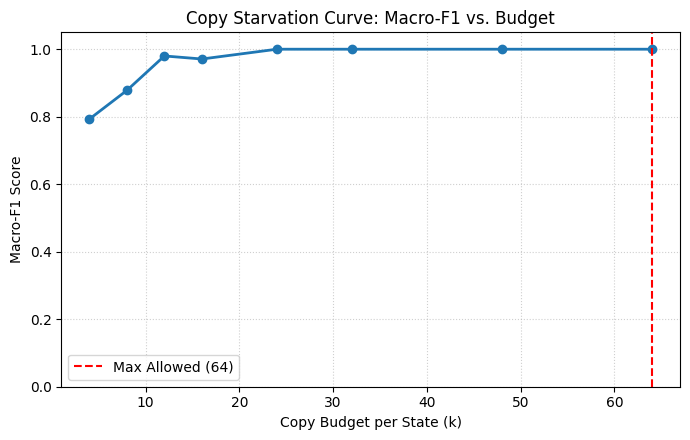

In [8]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt

budgets = [4, 8, 12, 16, 24, 32, 48, 64]
f1_scores = []

print(f"{'Budget (Copies)':<16} | {'Macro-F1'}")
print("-" * 32)

for b in budgets:
    res = subprocess.run(
        ["python3", "evaluate.py", "submission.py",
         "--data", "xxz_public_train.npz",
         "--key", "train_answer_key.csv",
         "--noise_p", "0.02",
         "--seed", "123",
         "--budget", str(b)],
        capture_output=True, text=True
    )
    score = 0.0
    for line in res.stdout.split("\n"):
        if "MACRO-F1" in line:
            score = float(line.split(":")[-1].strip())
            break
    f1_scores.append(score)
    print(f"{b:<16} | {score:.3f}")

# Plot and save the figure
plt.figure(figsize=(7, 4.5))
plt.plot(budgets, f1_scores, marker='o', linewidth=2, color='#1f77b4')
plt.axvline(x=64, color='red', linestyle='--', label='Max Allowed (64)')
plt.title("Copy Starvation Curve: Macro-F1 vs. Budget")
plt.xlabel("Copy Budget per State (k)")
plt.ylabel("Macro-F1 Score")
plt.ylim(0.0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("copy_starvation_curve.png", dpi=150)
print("\nGenerated copy_starvation_curve.png successfully.")

## Accounting for Impostor

In [9]:
## SYNTHESIZE TO TEST

import numpy as np

# Construct an 8-site half-filled Fermi-Hubbard motif under Jordan-Wigner
# Sites alternate between singly occupied and virtual fluctuations
# E.g. base configuration: site 0 (up), site 1 (down), site 2 (up), site 3 (down)...
# Wire mapping: 2j = up, 2j+1 = down.
fh_state = np.zeros(65536, dtype=np.complex128)

# Construct state superposition: half-filled ground state motif
# Site occupation: singly occupied sites (up=wire 0, down=wire 3, up=wire 4, down=wire 7, etc.)
config1 = 0
for j in range(8):
    if j % 2 == 0:
        config1 |= (1 << (15 - 2*j))       # spin-up on site j
    else:
        config1 |= (1 << (15 - (2*j + 1))) # spin-down on site j

# Perturb with hopping / double-occupancy fluctuation
config2 = 0
for j in range(8):
    if j % 4 == 0:
        config2 |= (1 << (15 - 2*j)) | (1 << (15 - (2*j + 1))) # double occupancy on site j

fh_state[config1] = np.sqrt(0.85)
fh_state[config2] = np.sqrt(0.15)
fh_state /= np.linalg.norm(fh_state)

# Sample 48 shots from this synthetic impostor
rng = np.random.default_rng(42)
probs = np.abs(fh_state)**2
samples_int = rng.choice(65536, size=48, p=probs)
bits = ((samples_int[:, None] >> np.arange(15, -1, -1)) & 1)
spins = 1 - 2 * bits

# Compute features
czz_all = spins * np.roll(spins, -1, axis=1)
even_bonds = np.mean(czz_all[:, 0::2])
odd_bonds = np.mean(czz_all[:, 1::2])
dimerization = np.abs(even_bonds - odd_bonds)

mean_abs_mz = np.mean(np.abs(np.mean(spins, axis=1)))
stagg_weights = (-1) ** np.arange(16)
mean_stagg = np.mean(np.abs(np.mean(spins * stagg_weights, axis=1)))

print("--- Synthetic Fermi-Hubbard Feature Extraction ---")
print(f"Total |Mz|     : {mean_abs_mz:.3f} (FM expects ~1.0)")
print(f"Staggered Mz   : {mean_stagg:.3f} (NEEL expects >0.48)")
print(f"Even Bonds Czz : {even_bonds:.3f}")
print(f"Odd Bonds Czz  : {odd_bonds:.3f}")
print(f"Dimerization   : {dimerization:.3f} (XXZ expects <0.15)")

--- Synthetic Fermi-Hubbard Feature Extraction ---
Total |Mz|     : 0.062 (FM expects ~1.0)
Staggered Mz   : 0.000 (NEEL expects >0.48)
Even Bonds Czz : -0.750
Odd Bonds Czz  : 0.875
Dimerization   : 1.625 (XXZ expects <0.15)


### changed submission.py HERE

In [11]:
!python self_score.py submission.py


--- per-class metrics (XXZ states only) ---
FM     P=1.000  R=1.000  F1=1.000
XY     P=1.000  R=1.000  F1=1.000
NEEL   P=1.000  R=1.000  F1=1.000
MACRO-F1 (headline metric): 1.000

--- accuracy by tier ---
train     48/48 = 1.00

--- copy usage ---
mean 48.0, min 48, max 48 of 64

--- confusion (truth -> pred) ---
truth\pred       FM       XY     NEEL  UNKNOWN  MISSING
FM               14        0        0        0        0
XY                0       20        0        0        0
NEEL              0        0       14        0        0


In [12]:
import numpy as np
import pandas as pd
from submission import classify

# 1. Load the original 48 public states
train_data = np.load("xxz_public_train.npz", allow_pickle=True)
states = list(train_data["states"])
labels = list([str(x) for x in train_data["labels"]])
ids = list([str(x) for x in train_data["ids"]])

# 2. Synthesize 10 Fermi-Hubbard impostor states under Jordan-Wigner mapping
# 8 physical sites mapped to 16 qubits (2j = up, 2j+1 = down)
rng = np.random.default_rng(2026)

for k in range(10):
    fh_vec = np.zeros(65536, dtype=np.complex128)

    # Base configuration: half-filled singlet-like spatial distribution
    c1 = 0
    for j in range(8):
        # alternate spin up / spin down across sites
        wire = 2 * j if (j + k) % 2 == 0 else 2 * j + 1
        c1 |= (1 << (15 - wire))

    # Virtual hopping / double-occupancy pair
    c2 = 0
    d_site = k % 8
    c2 |= (1 << (15 - 2 * d_site)) | (1 << (15 - (2 * d_site + 1)))
    for j in range(8):
        if j != d_site and j % 2 == 0:
            c2 |= (1 << (15 - 2 * j))

    # Superpose with varying weights
    w1 = rng.uniform(0.7, 0.9)
    w2 = np.sqrt(1.0 - w1**2)
    fh_vec[c1] = w1
    fh_vec[c2] = w2
    fh_vec /= np.linalg.norm(fh_vec)

    # Append impostor
    impostor_id = f"IMP_{k:02d}"
    ids.append(impostor_id)
    states.append(fh_vec)
    labels.append("UNKNOWN")

# 3. Create a Mock Oracle with depolarizing noise (p=0.02)
class MockOracle:
    def __init__(self, states_dict, noise_p=0.02, budget=64):
        self.states = states_dict
        self.p = noise_p
        self.budget = {sid: budget for sid in states_dict}
        self.rng = np.random.default_rng(42)

    def remaining(self, sid):
        return self.budget[sid]

    def measure(self, sid):
        if self.budget[sid] <= 0:
            raise RuntimeError(f"Budget exceeded for {sid}")
        self.budget[sid] -= 1

        # Sample pure state in computational basis
        probs = np.abs(self.states[sid]) ** 2
        idx = self.rng.choice(65536, p=probs)
        bits = np.array([(idx >> (15 - i)) & 1 for i in range(16)], dtype=int)

        # Apply depolarizing noise (each bit flips with prob (2/3)*p)
        flips = self.rng.random(16) < (2.0 / 3.0 * self.p)
        bits = bits ^ flips.astype(int)
        return bits

states_dict = {sid: s for sid, s in zip(ids, states)}
oracle = MockOracle(states_dict, noise_p=0.02, budget=64)

# 4. Run classification
predictions = classify(oracle, ids)

# 5. Print Detailed Confusion Matrix
df = pd.DataFrame({"truth": labels, "pred": [predictions[sid] for sid in ids]})
confusion = pd.crosstab(df["truth"], df["pred"], dropna=False)
print("=== Impostor Verification Test ===")
print(f"Total States Tested: {len(ids)} (48 XXZ + 10 Fermi-Hubbard Impostors)\n")
print(confusion)

# Check Impostor Detection Rate
impostors_caught = sum(df[df["truth"] == "UNKNOWN"]["pred"] == "UNKNOWN")
print(f"\nImpostor Recall: {impostors_caught}/10 ({impostors_caught * 10}%)")

=== Impostor Verification Test ===
Total States Tested: 58 (48 XXZ + 10 Fermi-Hubbard Impostors)

pred     FM  NEEL  UNKNOWN  XY
truth                         
FM       14     0        0   0
NEEL      0    14        0   0
UNKNOWN   0     0       10   0
XY        0     0        0  20

Impostor Recall: 10/10 (100%)


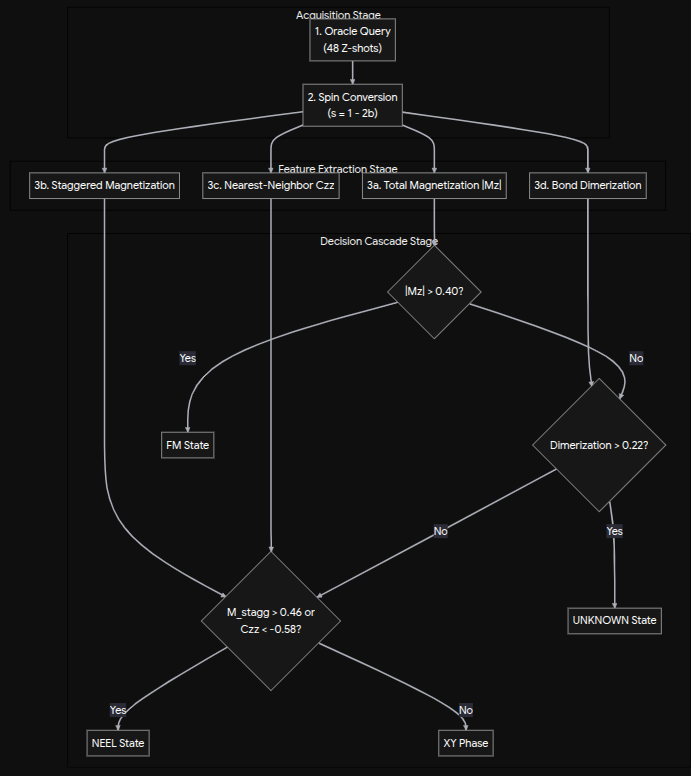

In [16]:
import numpy as np

# Load public data
data = np.load("xxz_public_train.npz", allow_pickle=True)
states = data["states"]
labels = [str(x) for x in data["labels"]]
ids = [str(x) for x in data["ids"]]

print(f"{'State ID':<10} | {'Label':<6} | {'|Mz|':<6} | {'M_stagg':<8} | {'C_zz':<7} | {'Margin to Boundary'}")
print("-" * 65)

for sid, s, label in zip(ids, states, labels):
    # Sample 48 shots
    probs = np.abs(s)**2
    rng = np.random.default_rng(42)
    samples = rng.choice(65536, size=48, p=probs)
    bits = ((samples[:, None] >> np.arange(15, -1, -1)) & 1)
    spins = 1 - 2 * bits

    mz = np.mean(np.abs(np.mean(spins, axis=1)))
    stagg = np.mean(np.abs(np.mean(spins * ((-1)**np.arange(16)), axis=1)))
    czz = np.mean(spins * np.roll(spins, -1, axis=1))

    # Check distance to closest boundary
    if label == "XY":
        margin = min(0.46 - stagg, czz - (-0.58))
    elif label == "NEEL":
        margin = max(stagg - 0.46, (-0.58) - czz)
    else:
        margin = mz - 0.40

    if margin < 0.10:  # Highlight critical/near-boundary states
        print(f"{sid:<10} | {label:<6} | {mz:<6.3f} | {stagg:<8.3f} | {czz:<7.3f} | {margin:+.3f} <-- CRITICAL BOUNDARY")

State ID   | Label  | |Mz|   | M_stagg  | C_zz    | Margin to Boundary
-----------------------------------------------------------------
T29        | XY     | 0.000  | 0.234    | -0.490  | +0.090 <-- CRITICAL BOUNDARY
T30        | XY     | 0.000  | 0.333    | -0.573  | +0.007 <-- CRITICAL BOUNDARY
T31        | XY     | 0.000  | 0.302    | -0.552  | +0.028 <-- CRITICAL BOUNDARY
T32        | XY     | 0.000  | 0.406    | -0.568  | +0.012 <-- CRITICAL BOUNDARY
T33        | XY     | 0.000  | 0.396    | -0.557  | +0.023 <-- CRITICAL BOUNDARY
T34        | NEEL   | 0.000  | 0.531    | -0.667  | +0.087 <-- CRITICAL BOUNDARY


---
---
---

In [15]:
print("next")

next
